# Versuch 4

## 1. RLC-Reihenschwingkreis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess
from moviepy import AudioFileClip
import librosa
import soundfile as sf
from IPython.display import Audio, Markdown

           (ms)       (V)     (V).1
0    -10.009923  0.000000  0.000000
1     -9.993995  1.020362  0.017286
2     -9.978067  1.020362  0.277498
3     -9.962139  1.020362  0.711184
4     -9.946211  1.020362  1.214198
...         ...       ...       ...
1255   9.979716  0.000000  0.000000
1256   9.995643  0.000000  0.000000
1257  10.011572  1.020362  0.086676
1258  10.027499  1.020362  0.398930
1259  10.043427  1.020362  0.884596

[1260 rows x 3 columns]


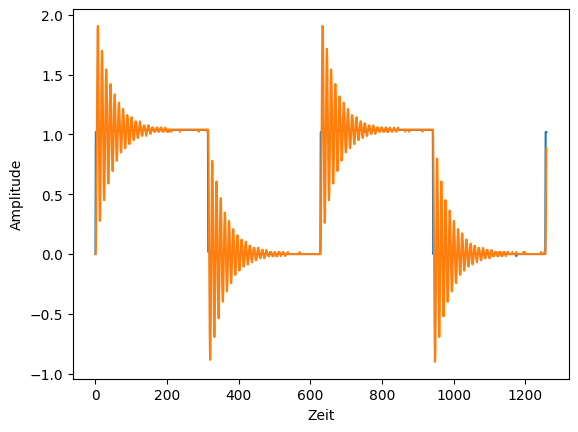

In [14]:
path = "signal_in-out.csv"
df = pd.read_csv(path, delimiter=";", decimal=",", header=1)
print(df)


plt.plot(df["(V)"])
plt.plot(df["(V).1"])
plt.xlabel("Zeit")
plt.ylabel("Amplitude")
plt.show()

## Digitale Frequenzweiche mit FFT-Filtern

In [ ]:


url = "https://www.youtube.com/watch?v=1T14eOUf-28"
start = 10
duration = 10
wav_out = "song.wav"
sr = 22050

# --- STEP 1: Download audio with yt-dlp ---
audio_path = "audio.mp3"
subprocess.run([
    "yt-dlp", "-f", "bestaudio", "-o", audio_path, url
])

# --- STEP 2: Cut audio with moviepy ---
clip = AudioFileClip(audio_path)
sub = clip.subclipped(start, start + duration)

# Export temporary WAV (16-bit PCM, librosa-friendly)
temp = "temp.wav"
sub.write_audiofile(temp, codec="pcm_s16le")

# --- STEP 3: Load with librosa ---
y, sr = librosa.load(temp, sr=sr, mono=True)
T = librosa.get_duration(y=y, sr=sr)

print("Audio shape:", y.shape)
print("Sampling rate:", sr)
print("Duration:", T)

Audio(data=y, rate=sr)

MoviePy - Writing audio in temp.wav


MoviePy - Done.
Audio shape: (220500,)
Sampling rate: 22050
Duration: 10.0


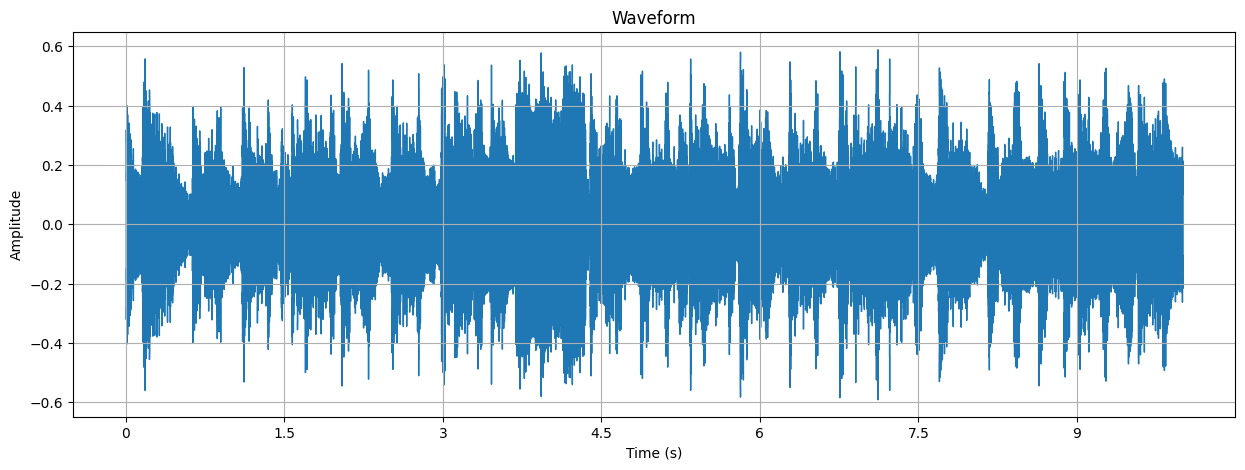

: 

In [ ]:
Markdown("### Song geplottet mit SR={} Hz und Dauer={} s".format(sr, T))
plt.figure(figsize=(15, 5))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()